# Bulldozer Sale Price Prediction
This project is from the [Kaggle Bluebook for Bulldozers competition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/overview)

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestRegressor

## Problem Definition
Predicting Bulldozer sale price based on history data
* Since we are predicting the future sale price of the item, it is defined as a regression problem 

## Data
Data is downloaded from [Kaggle](https://www.kaggle.com/competitions/bluebook-for-bulldozers/data)

* Train.csv is the training set, which contains data through the end of 2011.
* Valid.csv is the validation set, which contains data from January 1, 2012 - April 30, 2012
* Test.csv is the test set, which contains data from May 1, 2012 - November 2012.

In [75]:
train_df = pd.read_csv("data/Train.csv")
valid_df = pd.read_csv("data/Valid.csv")
test_df = pd.read_csv("data/Test.csv")

/var/folders/mf/3wt3q1y17_3fr_j24qtf31bm0000gn/T/ipykernel_32895/1727769340.py:1: DtypeWarning: Columns (0: fiModelSeries, 1: Coupler_System, 2: Grouser_Tracks, 3: Hydraulics_Flow) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("data/Train.csv")


In [40]:
train_df.shape, valid_df.shape, test_df.shape

((401125, 53), (11573, 52), (12457, 52))

**Our dataset contains:**

Training data: 401125 entries

Valid data: 11573 records

Test data: 12457 observations

In [46]:
train_df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='str')

**'SalePrice'** is our target, and the others are features

In [41]:
# Have a glance of the dataset
train_df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000,999089,3157,121,3.0,2004,68.0,Low,11/16/2006 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000,117657,77,121,3.0,1996,4640.0,Low,3/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000,434808,7009,121,3.0,2001,2838.0,High,2/26/2004 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500,1026470,332,121,3.0,2001,3486.0,High,5/19/2011 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000,1057373,17311,121,3.0,2007,722.0,Medium,7/23/2009 0:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Evaluation
The evaluation [metric for this this competition](www.kaggle.com/competitions/bluebook-for-bulldozers/overview/evaluation) is **RMSE**(root mean squared log error) between the actual and predicted auction price.

## Feature

* There is a data Dictionary provided by [the competition](https://www.kaggle.com/competitions/bluebook-for-bulldozers/data)

In [48]:
print(f"We have {len(train_df.columns)-1} features in our training dataset") # minus our target (i.e. SalePrice)

We have 52 features in our training dataset


## 1. Exploratory Data Analysis

In [77]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 401125 entries, 0 to 401124
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   401125 non-null  int64         
 1   SalePrice                 401125 non-null  int64         
 2   MachineID                 401125 non-null  int64         
 3   ModelID                   401125 non-null  int64         
 4   datasource                401125 non-null  int64         
 5   auctioneerID              380989 non-null  float64       
 6   YearMade                  401125 non-null  int64         
 7   MachineHoursCurrentMeter  142765 non-null  float64       
 8   UsageBand                 69639 non-null   str           
 9   saledate                  12457 non-null   datetime64[us]
 10  fiModelDesc               401125 non-null  str           
 11  fiBaseModel               401125 non-null  str           
 12  fiSecondaryDe

Seems like we have plenty of missing values. Also, some data types need to be transformed as regression models accepts numerical values exclusively.

Subsequently, I will go through features.

In [264]:
train_df['datasource'].value_counts()

datasource
132    260752
136     75491
149     26304
121     23979
172     14599
Name: count, dtype: int64

It turns out that there are 5 data source.
I suspect this feature matters much for the model.

* SalesID, MachineID, ModelID, auctioneerID are different identifiers.
    * Except for ModelID, the other IDs are unlikely to significantly affect our model. However, it needs to be verivied, so we will conduct a feature importance analysis to check whether this hypothesis holds true.
    * According to data dictionary, **ModelID** is associated with **fiModelDesc**. Thus, one of them could be dropped.
* Base on the data dictionary, **fiModelDesc** is Description of a unique machine model (see ModelID); concatenation of fiBaseModel & fiSecondaryDesc & fiModelSeries & fiModelDescriptor. Thus, 

In [119]:
# Checking if fiModelDesc can be represented by ModelID
# The result is correct

n_rows = 5
for _ in train_df['ModelID'].unique():
    print(f"ModelID : {_}")
    print(train_df[train_df['ModelID'] == _]['fiModelDesc'].head(n_rows))

ModelID : 3157
0        521D
1198     521D
5323     521D
11672    521D
11715    521D
Name: fiModelDesc, dtype: str
ModelID : 77
1      950FII
415    950FII
424    950FII
923    950FII
960    950FII
Name: fiModelDesc, dtype: str
ModelID : 7009
2      226
25     226
161    226
236    226
352    226
Name: fiModelDesc, dtype: str
ModelID : 332
3        PC120-6E
594      PC120-6E
3369     PC120-6E
12355    PC120-6E
13297    PC120-6E
Name: fiModelDesc, dtype: str
ModelID : 17311
4      S175
83     S175
196    S175
373    S175
551    S175
Name: fiModelDesc, dtype: str
ModelID : 4605
5      310G
10     310G
82     310G
134    310G
165    310G
Name: fiModelDesc, dtype: str
ModelID : 1937
6        790ELC
498      790ELC
8665     790ELC
18135    790ELC
20003    790ELC
Name: fiModelDesc, dtype: str
ModelID : 3539
7      416D
157    416D
201    416D
229    416D
277    416D
Name: fiModelDesc, dtype: str
ModelID : 36003
8        430HAG
2866     430HAG
4316     430HAG
5932     430HAG
16006    430HAG
N

I wanted to keep ModelID, and drop fiModelDesc. 

However, per data dictionary, the feature 'fiModelDesc' is concatenated by fiBaseModel & fiSecondaryDesc & fiModelSeries & fiModelDescriptor, so let me check how does the concatenation work.

In [130]:
# Checking the associateion among ModelID, 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelSeries', and 'fiModelDescriptor'
train_df[['ModelID', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelSeries', 'fiModelDescriptor' ]]

,ModelID,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelSeries,fiModelDescriptor
0,3157,521D,521,D,NaN,NaN,NaN
1,77,950FII,950,F,II,II,NaN
2,7009,226,226,NaN,NaN,NaN,NaN
3,332,PC120-6E,PC120,NaN,-6E,-6E,NaN
4,17311,S175,S175,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
401120,21439,35NX2,35,NX,2,2,NaN
401121,21439,35NX2,35,NX,2,2,NaN
401122,21439,35NX2,35,NX,2,2,NaN
401123,21435,30NX,30,NX,NaN,NaN,NaN


ModelID appears to function as an encoder that represents fiModelDesc.

Let me check on test and validation dataset whether the association between ModelID and fiModelDesc is consistent with that in the training dataset.

In [138]:
test_df[['ModelID', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelSeries', 'fiModelDescriptor' ]]

# n_rows = 5
# for _ in test_df['ModelID'].unique():
#     if _ == 3883: # comparing the ModelID in test dataset and training dataset
#         print(f"ModelID : {_}")
#         print(test_df[test_df['ModelID'] == _]['fiModelDesc'].head(n_rows))

,ModelID,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelSeries,fiModelDescriptor
0,3168,580G,580,G,NaN,NaN,NaN
1,7271,936,936,NaN,NaN,NaN,NaN
2,22805,EC210BLC,EC210,B,NaN,NaN,LC
3,1269,330CL,330,C,NaN,NaN,L
4,22312,650K,650,K,NaN,NaN,NaN
...,...,...,...,...,...,...,...
12452,21450,80NX3,80,NX,3,3,NaN
12453,21434,28N,28,N,NaN,NaN,NaN
12454,21437,35N,35,N,NaN,NaN,NaN
12455,21437,35N,35,N,NaN,NaN,NaN


In [141]:
valid_df[['ModelID', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelSeries', 'fiModelDescriptor' ]]

# n_rows = 5
# for _ in valid_df['ModelID'].unique():
#     if _ == 3883: # comparing the ModelID in test dataset and training dataset
#         print(f"ModelID : {_}")
#         print(valid_df[valid_df['ModelID'] == _]['fiModelDesc'].head(n_rows))

,ModelID,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelSeries,fiModelDescriptor
0,1376,375L,375,NaN,NaN,NaN,L
1,36526,TX300LC2,TX300,LC,2,2,NaN
2,4587,270LC,270,NaN,NaN,NaN,LC
3,1954,892DLC,892,D,NaN,NaN,LC
4,4701,544H,544,H,NaN,NaN,NaN
...,...,...,...,...,...,...,...
11568,21435,30NX,30,NX,NaN,NaN,NaN
11569,21436,30NX2,30,NX,2,2,NaN
11570,21435,30NX,30,NX,NaN,NaN,NaN
11571,21435,30NX,30,NX,NaN,NaN,NaN


The results confirm that ModelID is representing fiModelDesc, which is formed by concatenating fiBaseModel, fiSecondaryDesc, fiModelSeries, and fiModelDescriptor across the training, validation, and test sets.

Therefore, I decide to drop ‘fiBaseModel’, ‘fiSecondaryDesc’, ‘fiModelSeries’, and ‘fiModelDescriptor’ to avoid redundancy.

In [307]:
print("Year : Count")
for year, count in zip(train_df['YearMade'].value_counts().keys(), train_df['YearMade'].value_counts()):
    print(f"{year} : {count}")

Year : Count
1000 : 38185
1998 : 21221
2005 : 20587
2004 : 20020
1997 : 18905
1999 : 18767
2000 : 16742
1996 : 16691
1995 : 15528
1994 : 14199
2003 : 14161
2001 : 12938
2006 : 12215
2002 : 12031
1993 : 10971
1989 : 10693
1988 : 10395
1990 : 10250
1987 : 10105
1992 : 7587
1986 : 7508
1991 : 7361
1985 : 6475
1984 : 6111
1978 : 5623
1979 : 5557
1980 : 4677
1983 : 4557
2007 : 4523
1977 : 4379
1981 : 4144
1975 : 3192
1974 : 3079
1982 : 3018
1976 : 2694
1973 : 2521
1972 : 2119
1971 : 1705
1969 : 1529
2008 : 1422
1970 : 1314
1968 : 1247
1967 : 1086
1966 : 943
1965 : 667
1964 : 414
1963 : 246
2009 : 168
1962 : 143
1919 : 127
1961 : 99
1960 : 97
1959 : 28
2010 : 25
1958 : 22
1956 : 20
2011 : 18
1920 : 17
1957 : 15
1950 : 8
1951 : 7
1952 : 6
1953 : 6
1955 : 5
1948 : 3
1954 : 3
1942 : 1
1937 : 1
1949 : 1
1947 : 1
2012 : 1
2013 : 1


Majority of products were made 40 years ago (This year is 2026)

The oldest and the most products were recorded to be made more than 1000 years ago, which is unreasonable The entries are likely to be recorded incorrectly.

On the other hand, the leatest models were made in 2013, and there is only one entry.

The actual manufacturing years likely range from the early 1900s to 2013.

Proportion of missing values in UsageBand : 82.64 %


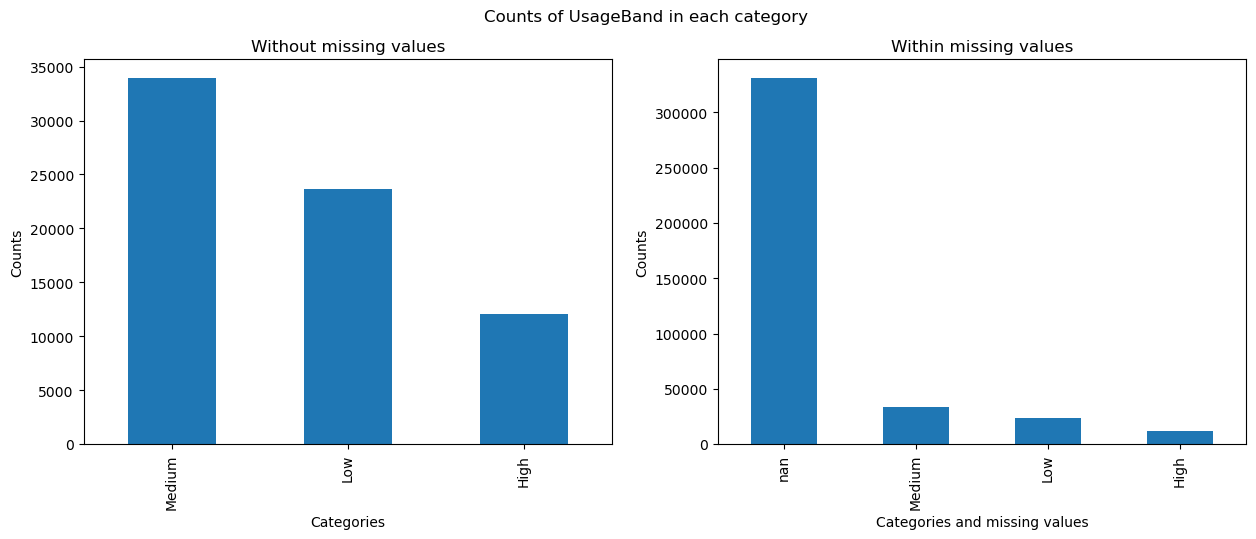

In [326]:
print(f"Proportion of missing values in UsageBand : { train_df['UsageBand'].isna().sum() / train_df.shape[0] * 100 :.2f} %")

fig, (ax0, ax1) = plt.subplots(figsize = (15, 5),
                              nrows = 1,
                              ncols = 2)

train_df['UsageBand'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "Without missing values",
       xlabel= "Categories",
       ylabel = "Counts")

train_df['UsageBand'].value_counts(dropna=False).plot.bar(ax = ax1)
ax1.set(title = "Within missing values",
        xlabel = "Categories and missing values",
        ylabel = "Counts")

fig.suptitle("Counts of UsageBand in each category");

The majority of UsageBand is Medium. However, the proportion of missing values is up to 80%.

* UsageBand is ordernal categorical. I will transform the datatype later.
* I will fill the missing data with "Medium"

**MachineHoursCurrentMeter:** 

current usage of the machine in hours at time of sale (saledate);  null or 0 means no hours have been reported for that sale

count    1.427650e+05
mean     3.457955e+03
std      2.759026e+04
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      3.025000e+03
max      2.483300e+06
Name: MachineHoursCurrentMeter, dtype: float64


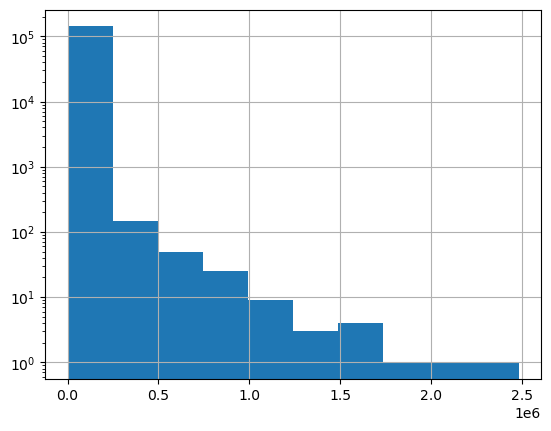

In [342]:
print(train_df['MachineHoursCurrentMeter'].describe())
train_df['MachineHoursCurrentMeter'].hist(log = True);

Proportion of missing values in Productsize : 52.55 %


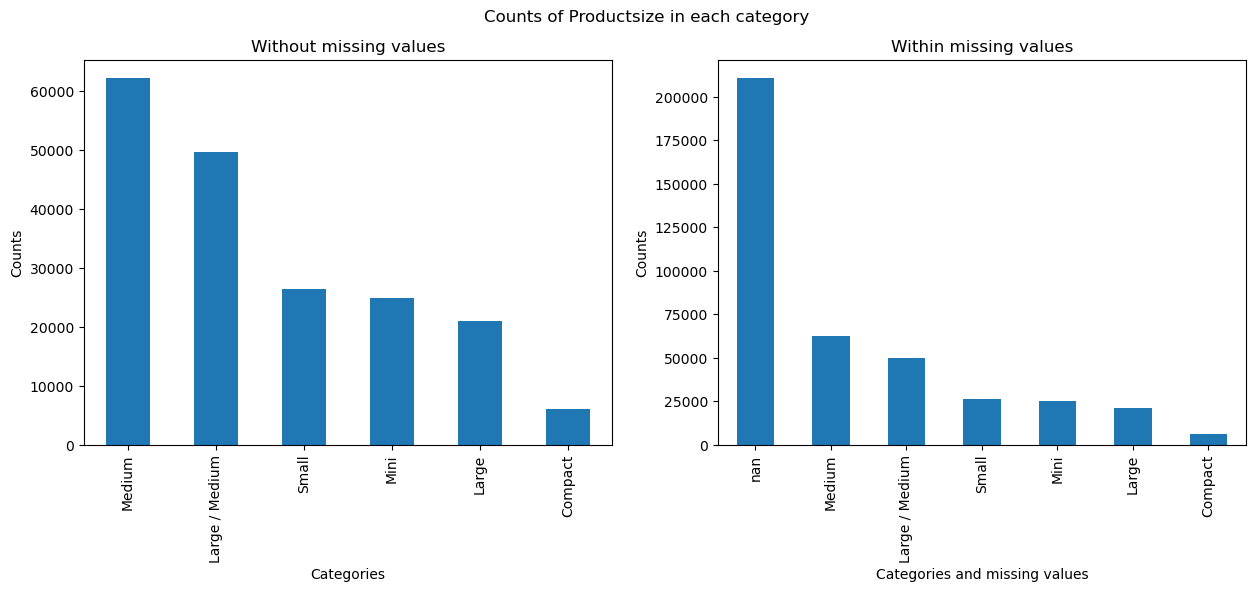

In [261]:
print(f"Proportion of missing values in Productsize : { train_df['ProductSize'].isna().sum() / train_df.shape[0] * 100 :.2f} %")
fig, (ax0, ax1) = plt.subplots(figsize = (15, 5),
                              nrows = 1,
                              ncols = 2)

train_df['ProductSize'].value_counts().plot.bar(ax = ax0)
ax0.set(title = "Without missing values",
       xlabel= "Categories",
       ylabel = "Counts")

train_df['ProductSize'].value_counts(dropna=False).plot.bar(ax = ax1)
ax1.set(title = "Within missing values",
        xlabel = "Categories and missing values",
        ylabel = "Counts")

fig.suptitle("Counts of Productsize in each category");

The following insights are derived from the bar graphs above:

* Missing values in ProductSize account for up to more than half of the training dataset. In other word, we have less than half data in this feature.
* In terms of **Large/Medium** category, it appears to indicate uncertainty as to whether the instance should be classified as Large or Medium
* Medium size appears to have the highest frequency.

Given that the most products fall into the Medium category, missing values will be imputed accordingly.

In [349]:
train_df['ProductGroup'].unique()

<ArrowStringArray>
['WL', 'SSL', 'TEX', 'BL', 'TTT', 'MG']
Length: 6, dtype: str

In [350]:
train_df['fiProductClassDesc'].unique()

<ArrowStringArray>
[                        'Wheel Loader - 110.0 to 120.0 Horsepower',
                         'Wheel Loader - 150.0 to 175.0 Horsepower',
       'Skid Steer Loader - 1351.0 to 1601.0 Lb Operating Capacity',
            'Hydraulic Excavator, Track - 12.0 to 14.0 Metric Tons',
       'Skid Steer Loader - 1601.0 to 1751.0 Lb Operating Capacity',
          'Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth',
            'Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons',
              'Hydraulic Excavator, Track - 3.0 to 4.0 Metric Tons',
                         'Wheel Loader - 350.0 to 500.0 Horsepower',
              'Track Type Tractor, Dozer - 20.0 to 75.0 Horsepower',
            'Hydraulic Excavator, Track - 19.0 to 21.0 Metric Tons',
              'Hydraulic Excavator, Track - 4.0 to 5.0 Metric Tons',
              'Hydraulic Excavator, Track - 2.0 to 3.0 Metric Tons',
            'Hydraulic Excavator, Track - 24.0 to 28.0 Metric Tons',
               

In [144]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 401125 entries, 0 to 401124
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   SalesID                   401125 non-null  int64         
 1   SalePrice                 401125 non-null  int64         
 2   MachineID                 401125 non-null  int64         
 3   ModelID                   401125 non-null  int64         
 4   datasource                401125 non-null  int64         
 5   auctioneerID              380989 non-null  float64       
 6   YearMade                  401125 non-null  int64         
 7   MachineHoursCurrentMeter  142765 non-null  float64       
 8   UsageBand                 69639 non-null   str           
 9   saledate                  12457 non-null   datetime64[us]
 10  fiModelDesc               401125 non-null  str           
 11  fiBaseModel               401125 non-null  str           
 12  fiSecondaryDe

## Data Pre-processing

* drop features - ‘fiBaseModel’, ‘fiSecondaryDesc’, ‘fiModelSeries’, and ‘fiModelDescriptor’
* Transforming Data type
    * `YearMade` -> datetime
    * `UsageBand` -> ordernal category
    * `saledate` -> datetime
* Handling Missing Values:
    * Missing values in `ProductSize` will be imputed with **Medium**
    * Missing values in `UsageBand` will be imputed with **Medium**


In [76]:
train_df['saledate'] = pd.to_datetime(test_df['saledate'])
train_df['saledate']

0        2012-05-03
1        2012-05-10
2        2012-05-10
3        2012-05-10
4        2012-05-10
            ...    
401120          NaT
401121          NaT
401122          NaT
401123          NaT
401124          NaT
Name: saledate, Length: 401125, dtype: datetime64[us]